In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes # using dataset from sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline

## <u>Load Dataset</u>

In [2]:
data = load_diabetes(as_frame = True).frame
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [3]:
# no scaling or feature engineering or encoding needed as the dataset is pretty clean

## <u>train_test_split</u>

In [4]:
X = data.drop(columns = ["target"])
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## <u>Create and train the model </u>

In [5]:
dt_regressor_model = DecisionTreeRegressor()
dt_regressor_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## <u>Predict and Evaluate</u>

In [6]:
# we will make predictions for both traning and testing data to check overfitting or underfiting of our model
# if training score = 0.9 and test score = 0.3, overfitting model, high variance
# if training score = 0.3 and test score = 0.3, underfitting model, high bias
# if training score = 0.9 and test score = 0.85, good model, balanced variance and bias

y_pred_training = dt_regressor_model.predict(X_train)
y_pred_test = dt_regressor_model.predict(X_test)

print("For decision tree regressor :-\n")

print("Training data evaluation :- \n")
print("R Squared score : ", r2_score(y_train, y_pred_training))
print("MSE : ", mean_squared_error(y_train, y_pred_training))

print("Test data evaluation :- \n")
print("R Squared score : ", r2_score(y_test, y_pred_test))
print("MSE : ", mean_squared_error(y_test, y_pred_test))

# we got r squared score for training data as 1 and mse for training data as 0 which means our model is extremely overfitting

For decision tree regressor :-

Training data evaluation :- 

R Squared score :  1.0
MSE :  0.0
Test data evaluation :- 

R Squared score :  -0.12474400377519612
MSE :  6071.714285714285


## <u>Plot the Tree</u>

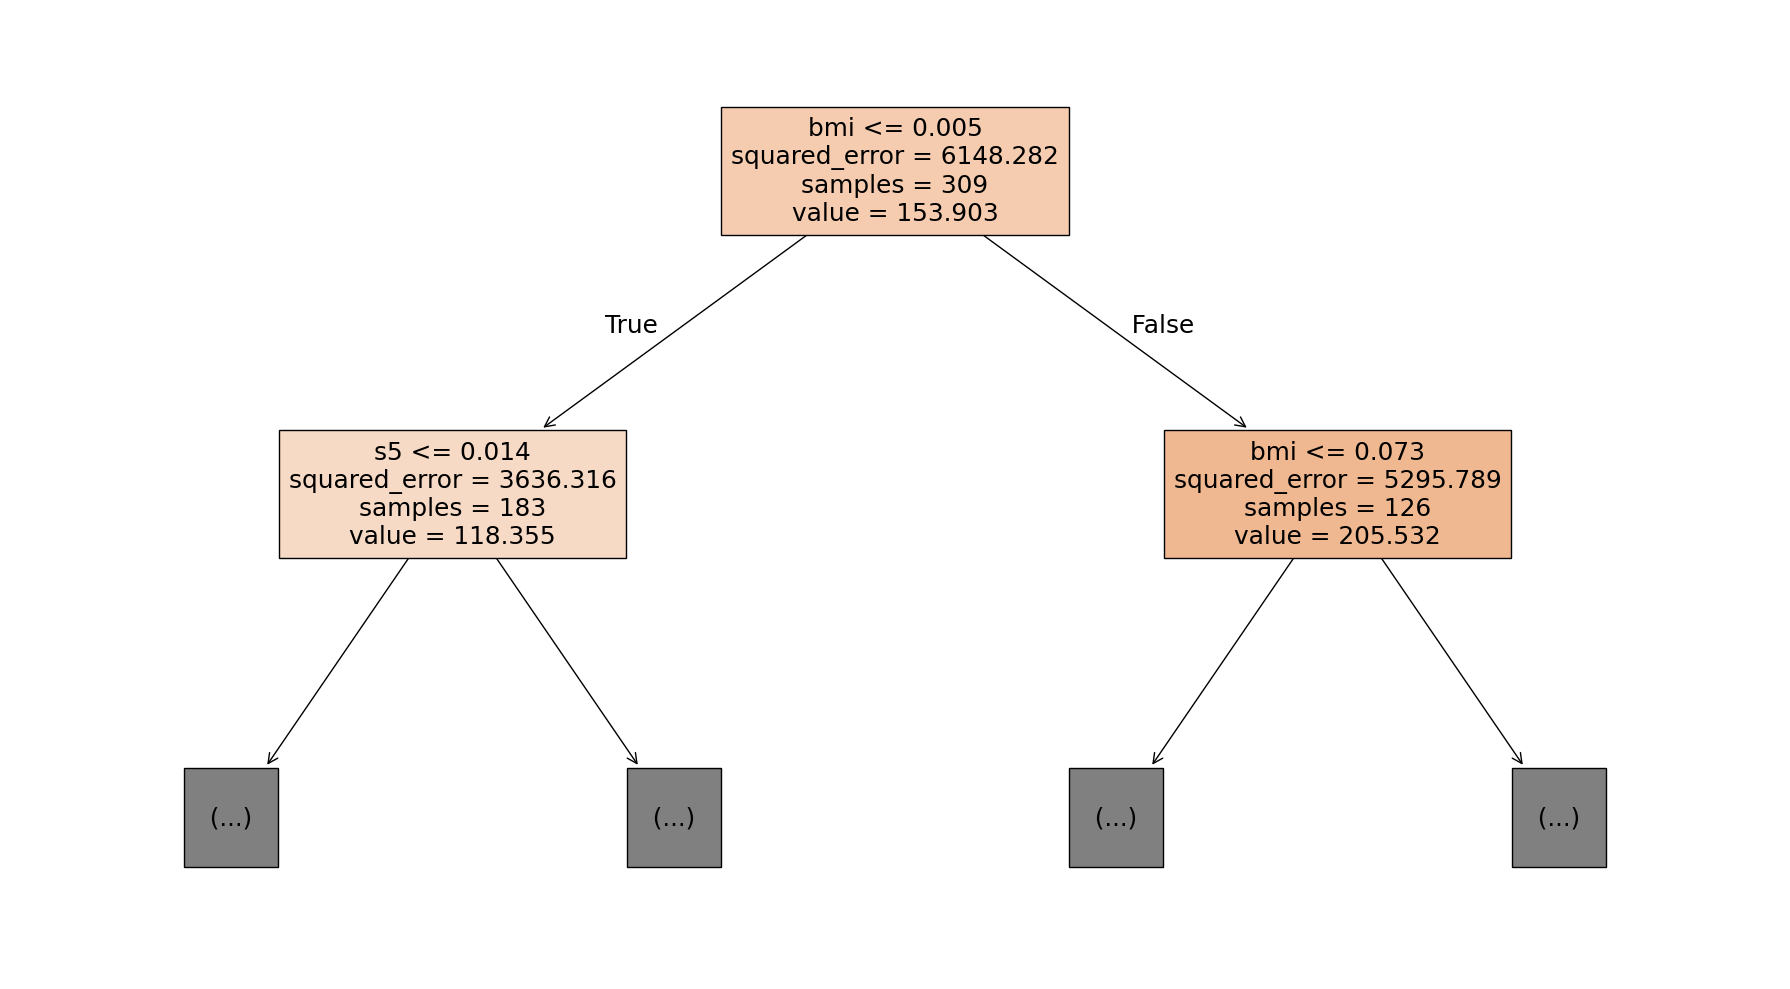

In [7]:
plt.figure(figsize=(18,10))

plot_tree(
    dt_regressor_model,
    feature_names = X.columns,
    filled=True,
    max_depth = 1 # the levels are in 20's but for us to see we choose max_depth low
)

plt.tight_layout()
plt.show()

## <u>Hyperparamter Pruning</u>

In [9]:
# again we make a pipeline, pass the pre pruning paramter list and use gridsearch cv to find best hyperparameters 

full_tree = DecisionTreeRegressor(random_state = 42)
full_tree.fit(X_train, y_train)

path = full_tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas

max_depth_list = np.arange(2,40,2)
min_samples_leaf_list = np.arange(1,20,1)
min_samples_split_list = np.arange(5,40,5)

ccp_alphas_reduced = ccp_alphas[::10] # Only take every 10th alpha to reduce size

print(ccp_alphas_reduced)

steps = [("dt",DecisionTreeRegressor(random_state = 42))]
pipeline = Pipeline(steps)

param_grid = {
    "dt__max_depth" : max_depth_list ,
    "dt__min_samples_leaf" : min_samples_leaf_list,
    "dt__min_samples_split" : min_samples_split_list,
    "dt__ccp_alpha" : ccp_alphas_reduced
}

dt_regressor_cv_model = GridSearchCV(
    pipeline,
    param_grid,
    cv = 5
)

dt_regressor_cv_model.fit(X_train, y_train)

y_pred_training = dt_regressor_cv_model.predict(X_train)
y_pred_test = dt_regressor_cv_model.predict(X_test)

print("Best hyper paramters : ", dt_regressor_cv_model.best_params_)


print("For decision tree regressor (Pre pruning) :-\n")

print("Training data evaluation :- \n")
print("R Squared score : ", r2_score(y_train, y_pred_training))
print("MSE : ", mean_squared_error(y_train, y_pred_training))

print("\nTest data evaluation :- \n")
print("R Squared score : ", r2_score(y_test, y_pred_test))
print("MSE : ", mean_squared_error(y_test, y_pred_test))

[0.00000000e+00 1.61812298e-03 6.47249191e-03 1.45631068e-02
 2.58899676e-02 2.58899676e-02 4.04530744e-02 7.92880259e-02
 1.17718447e-01 1.74757282e-01 2.37864078e-01 3.45343402e-01
 4.53613808e-01 5.52319310e-01 7.78856526e-01 9.97303128e-01
 1.34843581e+00 2.25802127e+00 2.87815534e+00 3.84735707e+00
 5.36450917e+00 6.99029126e+00 9.68500539e+00 1.34786408e+01
 2.02253506e+01 2.91909745e+01 4.19294934e+01 9.40396254e+01]
Best hyper paramters :  {'dt__ccp_alpha': np.float64(94.03962542312098), 'dt__max_depth': np.int64(6), 'dt__min_samples_leaf': np.int64(8), 'dt__min_samples_split': np.int64(35)}
For decision tree regressor (Pre pruning) :-

Training data evaluation :- 

R Squared score :  0.528147754258939
MSE :  2901.080591849012

Test data evaluation :- 

R Squared score :  0.3926280161545931
MSE :  3278.780894744709


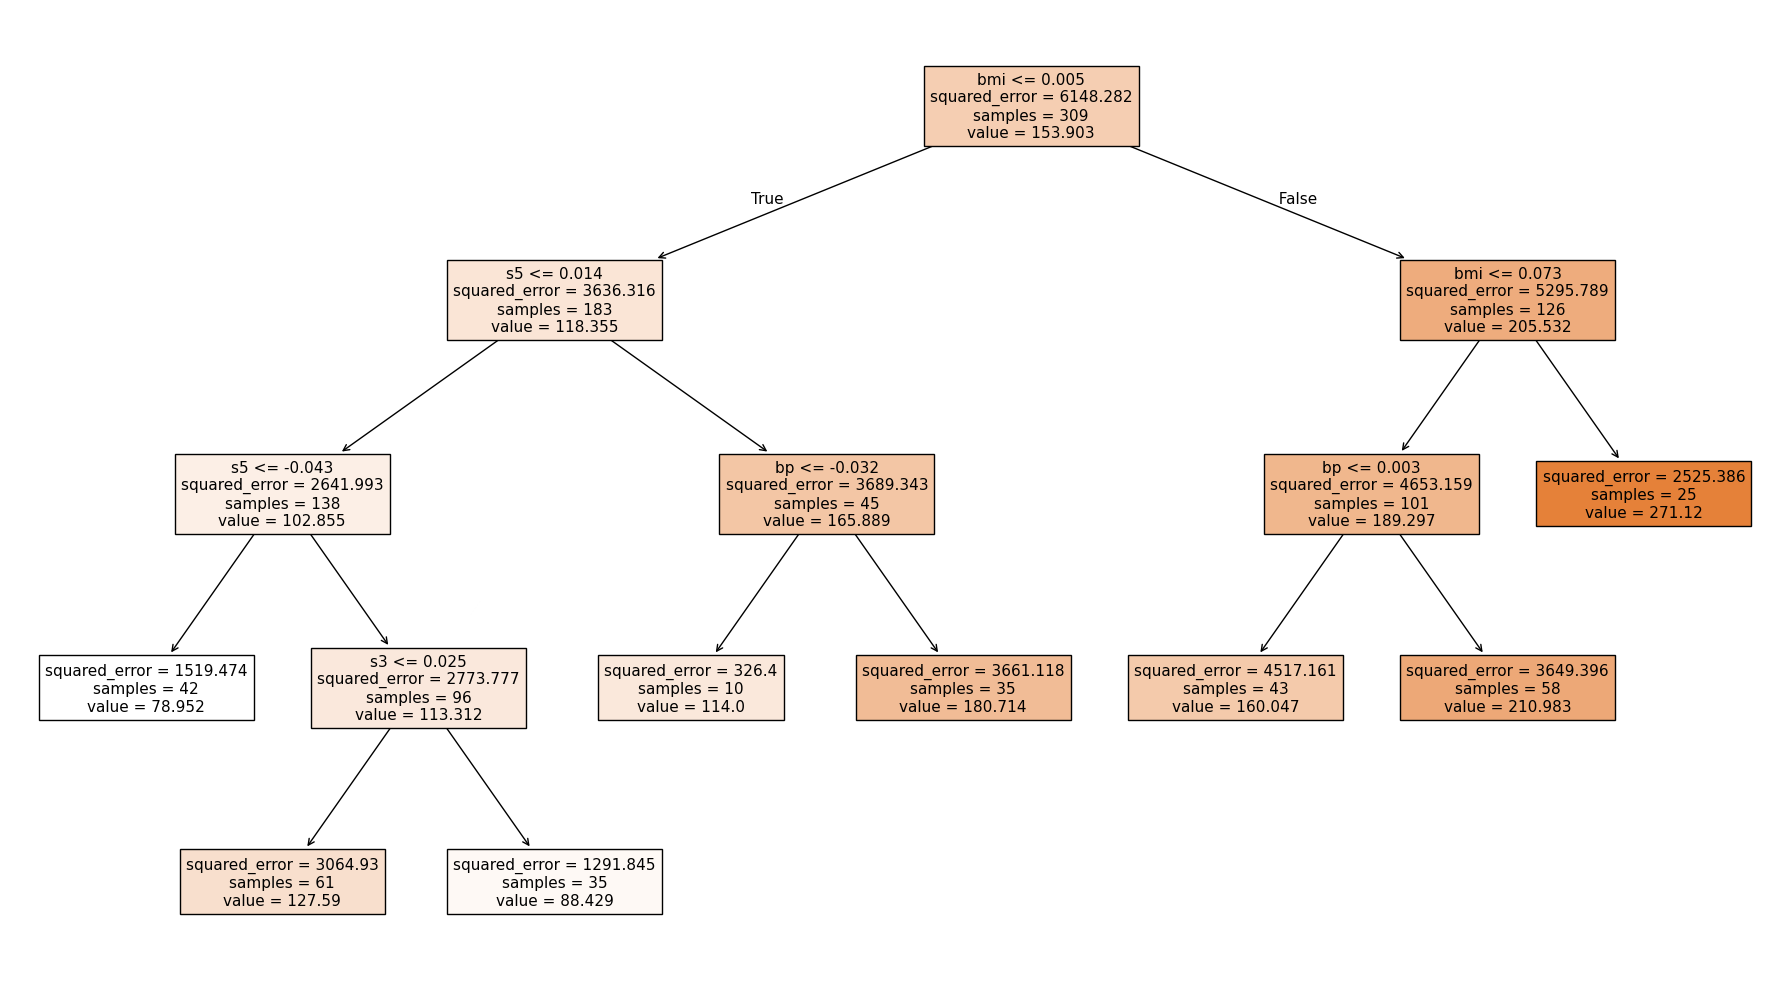

In [12]:
plt.figure(figsize=(18,10))

best_pipeline = dt_regressor_cv_model.best_estimator_ 

best_dt_regressor = best_pipeline.named_steps["dt"] 

plot_tree(
    best_dt_regressor,
    feature_names = X.columns,
    filled=True,
    # max_depth = 2
)

plt.tight_layout()
plt.show()